In [ ]:
from google.colab import files
uploaded = files.upload()

Saving dogs-vs-cats.zip to dogs-vs-cats (1).zip


In [ ]:
import zipfile

with zipfile.ZipFile("dogs-vs-cats.zip", "r") as zip_ref:
    zip_ref.extractall()

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
train_cat = "training_set/training_set/cats"
train_dog = "training_set/training_set/dogs"

test_cat = "test_set/test_set/cats"
test_dog = "test_set/test_set/dogs"

In [ ]:
IMG_SIZE = 64

X = []
y = []

limit = 1000

In [ ]:
count = 0

for img in os.listdir(train_cat):

    if img.startswith("."):
        continue

    if count >= limit:
        break

    path = os.path.join(train_cat, img)

    image = cv2.imread(path)

    if image is None:
        continue

    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    X.append(image.flatten())

    y.append(0)

    count += 1

In [ ]:
count = 0

for img in os.listdir(train_dog):

    if img.startswith("."):
        continue

    if count >= limit:
        break

    path = os.path.join(train_dog, img)

    image = cv2.imread(path)

    if image is None:
        continue

    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    X.append(image.flatten())

    y.append(1)

    count += 1

In [ ]:
X = np.array(X, dtype=np.float32) / 255.0
y = np.array(y)

print(X.shape)
print(y.shape)

(2000, 12288)
(2000,)


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)

svm.fit(X_train, y_train)

SVC(C=10)

In [ ]:
y_pred = svm.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))

Accuracy: 0.6575


In [ ]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.66      0.66      0.66       200
           1       0.66      0.66      0.66       200

    accuracy                           0.66       400
   macro avg       0.66      0.66      0.66       400
weighted avg       0.66      0.66      0.66       400



In [ ]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.66      0.66      0.66       200
           1       0.66      0.66      0.66       200

    accuracy                           0.66       400
   macro avg       0.66      0.66      0.66       400
weighted avg       0.66      0.66      0.66       400



In [ ]:
cm = confusion_matrix(y_val, y_pred)

print(cm)

[[131  69]
 [ 68 132]]


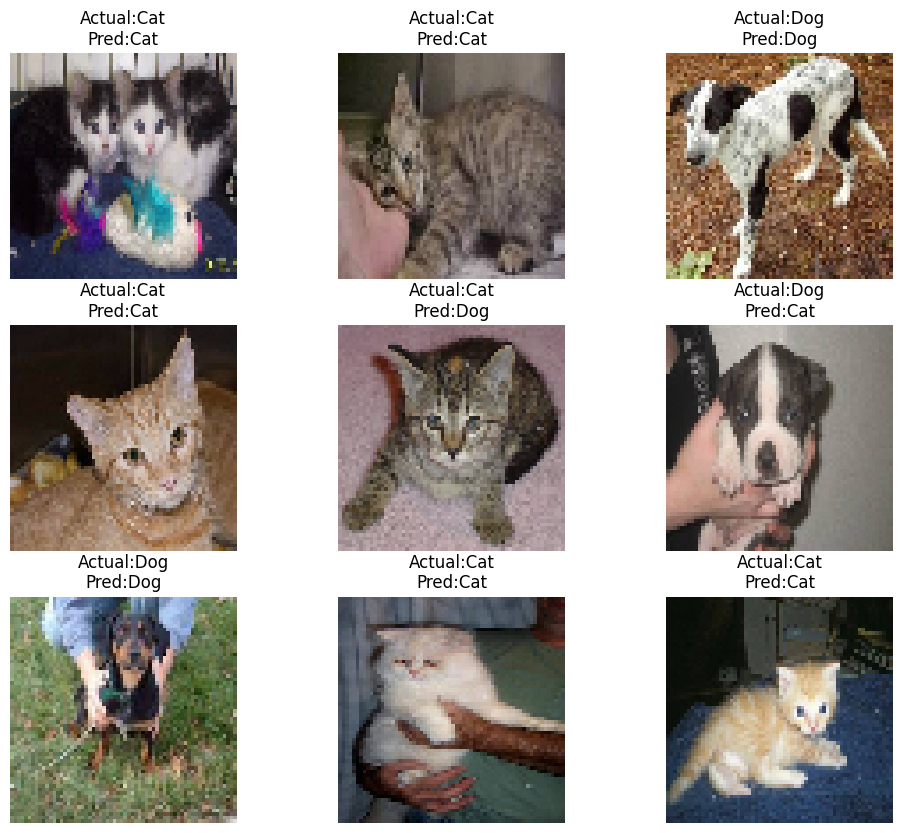

In [ ]:
plt.figure(figsize=(12,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    img = X_val[i].reshape(64,64,3)

    plt.imshow(img)

    actual = "Cat" if y_val[i]==0 else "Dog"
    pred = "Cat" if y_pred[i]==0 else "Dog"

    plt.title(f"Actual:{actual}\nPred:{pred}")

    plt.axis("off")

plt.show()

In [ ]:
X_test = []
y_test = []

In [ ]:
for img in os.listdir(test_cat):

    if img.startswith("."):
        continue

    path = os.path.join(test_cat, img)

    image = cv2.imread(path)

    if image is None:
        continue

    image = cv2.resize(image,(64,64))
    image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

    X_test.append(image.flatten())

    y_test.append(0)

In [ ]:
for img in os.listdir(test_dog):

    if img.startswith("."):
        continue

    path = os.path.join(test_dog, img)

    image = cv2.imread(path)

    if image is None:
        continue

    image = cv2.resize(image,(64,64))
    image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

    X_test.append(image.flatten())

    y_test.append(1)

In [ ]:
X_test = np.array(X_test, dtype=np.float32) / 255.0
y_test = np.array(y_test)

In [ ]:
test_pred = svm.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, test_pred))

Test Accuracy: 0.6193771626297578


In [ ]:
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       0.61      0.64      0.63      1011
           1       0.63      0.60      0.61      1012

    accuracy                           0.62      2023
   macro avg       0.62      0.62      0.62      2023
weighted avg       0.62      0.62      0.62      2023



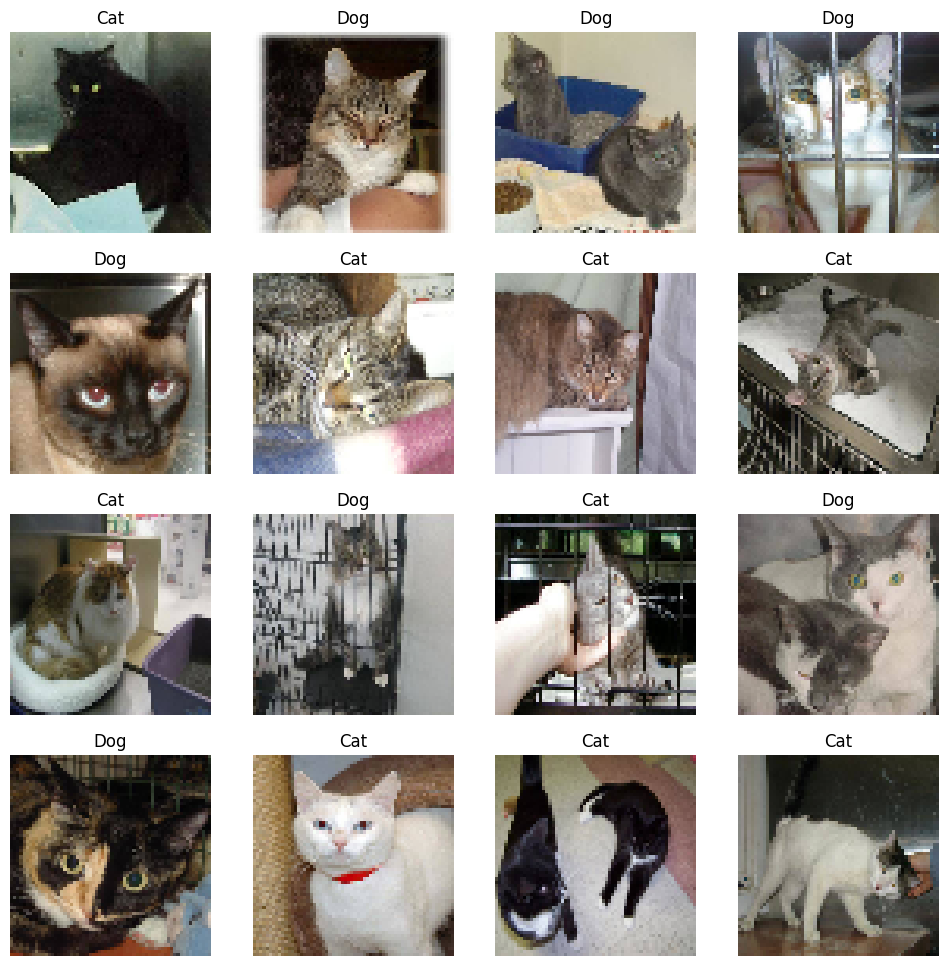

In [ ]:
plt.figure(figsize=(12,12))

for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(X_test[i].reshape(64,64,3))

    label = "Cat" if test_pred[i]==0 else "Dog"

    plt.title(label)

    plt.axis("off")

plt.show()

In [ ]:
print("Training Accuracy:", svm.score(X_train, y_train))

Training Accuracy: 1.0


In [ ]:
print("Test Accuracy:", accuracy_score(y_test, test_pred))

Test Accuracy: 0.6193771626297578


In [ ]:
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       0.61      0.64      0.63      1011
           1       0.63      0.60      0.61      1012

    accuracy                           0.62      2023
   macro avg       0.62      0.62      0.62      2023
weighted avg       0.62      0.62      0.62      2023



In [ ]:
print(confusion_matrix(y_test, test_pred))

[[649 362]
 [408 604]]


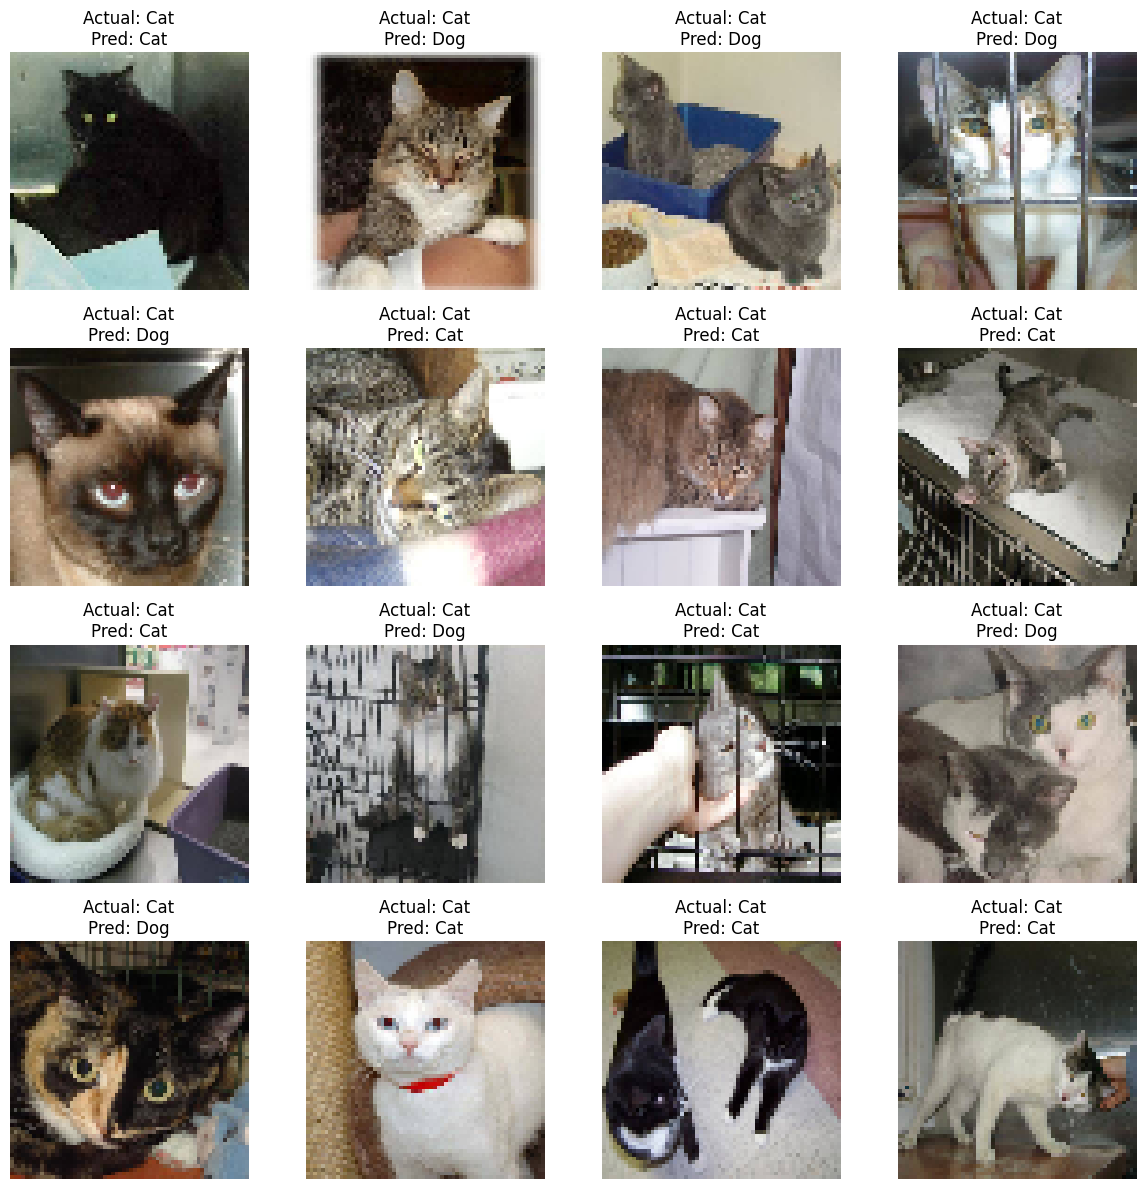

In [ ]:
plt.figure(figsize=(12,12))

for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(X_test[i].reshape(64,64,3))

    actual = "Cat" if y_test[i] == 0 else "Dog"
    predicted = "Cat" if test_pred[i] == 0 else "Dog"

    plt.title(f"Actual: {actual}\nPred: {predicted}")

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
print("Training Accuracy:", svm.score(X_train, y_train))
print("Test Accuracy:", accuracy_score(y_test, test_pred))

Training Accuracy: 1.0
Test Accuracy: 0.6193771626297578


In [ ]:
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       0.61      0.64      0.63      1011
           1       0.63      0.60      0.61      1012

    accuracy                           0.62      2023
   macro avg       0.62      0.62      0.62      2023
weighted avg       0.62      0.62      0.62      2023



In [ ]:
print(confusion_matrix(y_test, test_pred))

[[649 362]
 [408 604]]


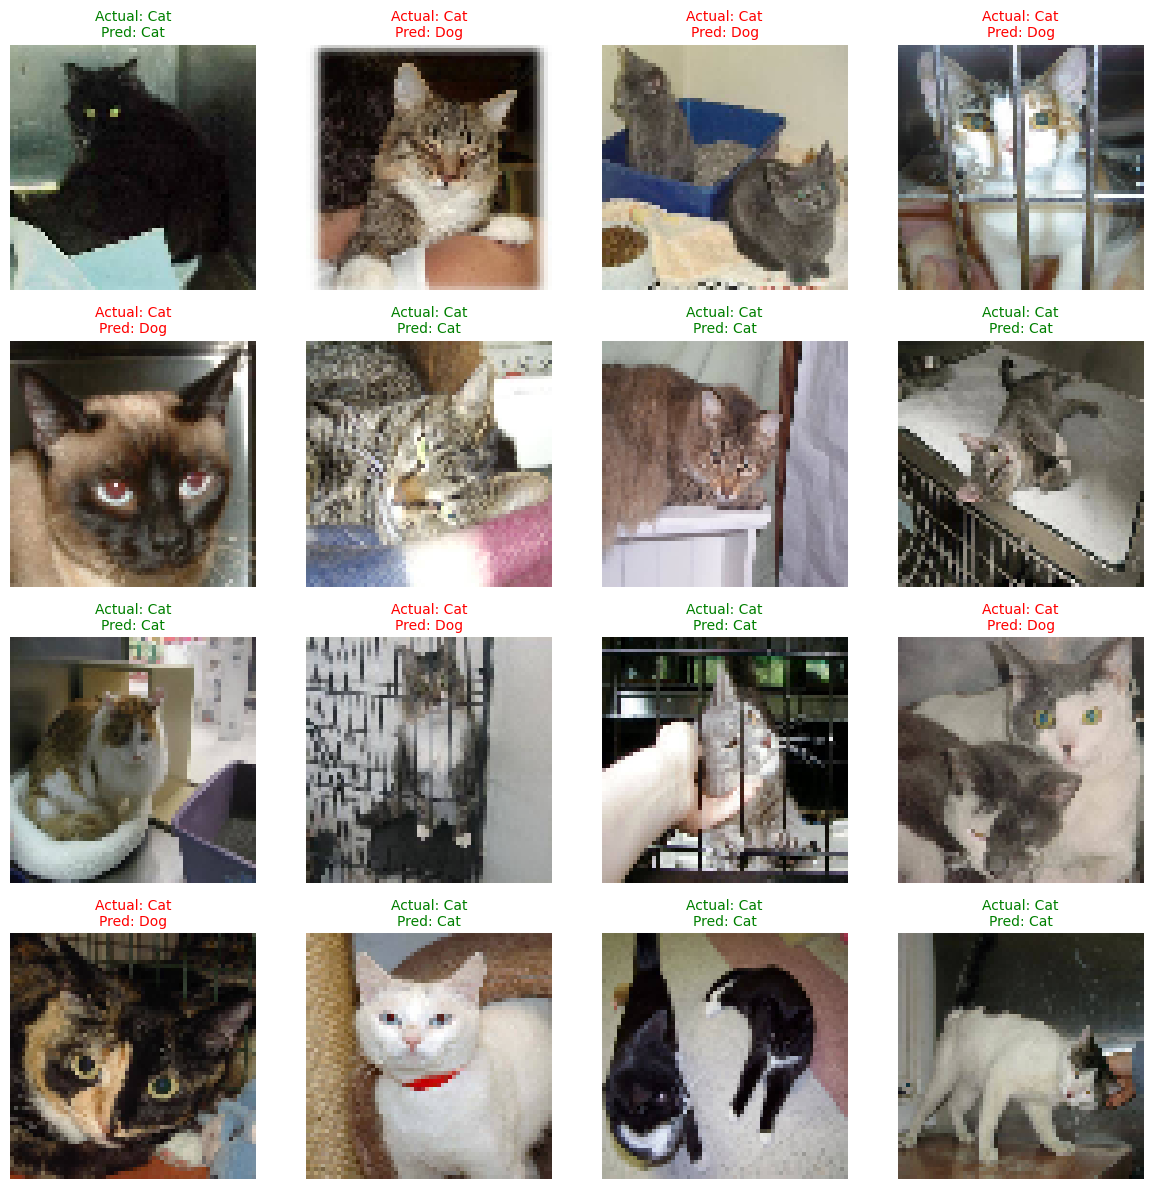

In [ ]:
plt.figure(figsize=(12,12))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(X_test[i].reshape(64,64,3))

    actual = "Cat" if y_test[i] == 0 else "Dog"
    predicted = "Cat" if test_pred[i] == 0 else "Dog"

    color = "green" if actual == predicted else "red"

    plt.title(f"Actual: {actual}\nPred: {predicted}",
              color=color, fontsize=10)

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
print("Training Accuracy:", svm.score(X_train, y_train))
print("Testing Accuracy:", accuracy_score(y_test, test_pred))

Training Accuracy: 1.0
Testing Accuracy: 0.6193771626297578


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       0.61      0.64      0.63      1011
           1       0.63      0.60      0.61      1012

    accuracy                           0.62      2023
   macro avg       0.62      0.62      0.62      2023
weighted avg       0.62      0.62      0.62      2023



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, test_pred)
print(cm)

[[649 362]
 [408 604]]


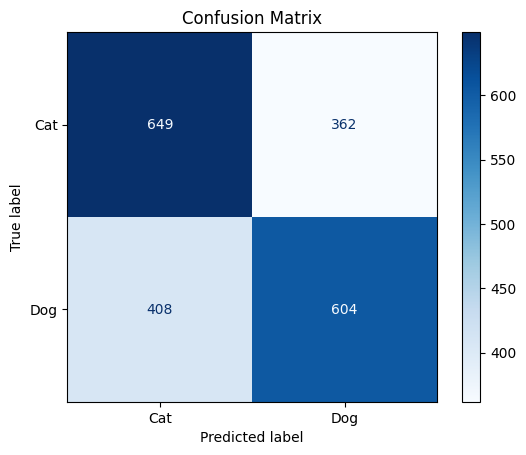

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred,
    display_labels=["Cat", "Dog"],
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()